In [1]:
import numpy as np
import torch
import cv2
import rasterio

from ultralytics import YOLO
from ultralytics.data.augment import LetterBox

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
MODEL_PATH = "/Users/leonheintz/Desktop/DS_AI_project/Data-Science-AI-Mauseschaden/yolo11m_best.pt"
IMAGE_PATH = "/Users/leonheintz/Desktop/DS_AI_project/Data-Science-AI-Mauseschaden/new_dataset/250227Reichardtswerben_1852_x123120_y7600_w840_h840_DJI_RGB2.tif"

CLASS_ID = 0
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
def load_tif_as_rgb_uint8(path: str) -> np.ndarray:
    with rasterio.open(path) as src:
        img = src.read()  # (bands, H, W)

    img = np.transpose(img, (1, 2, 0))  # (H, W, C)

    if img.shape[2] > 3:
        img = img[:, :, :3]
    if img.shape[2] == 1:
        img = np.repeat(img, 3, axis=2)

    img = img.astype(np.float32)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    img = (img * 255.0).clip(0, 255).astype(np.uint8)

    return img  # RGB uint8

In [4]:
def preprocess_ultralytics(img_rgb_uint8: np.ndarray, imgsz: int = 832, device: str = "cpu") -> torch.Tensor:
    """
    Macht YOLO-typisches Letterbox/Padding auf imgsz×imgsz.
    imgsz sollte ein Vielfaches von 32 sein (z.B. 832, 864, 896, ...).
    """
    lb = LetterBox(new_shape=(imgsz, imgsz), auto=False, scaleFill=False, stride=32)
    im = lb(image=img_rgb_uint8)  # HWC uint8, gepadded/resized

    x = im.astype(np.float32) / 255.0
    x = np.transpose(x, (2, 0, 1))     # CHW
    x = torch.from_numpy(x).unsqueeze(0).to(device)  # BCHW
    return x

In [5]:
yolo = YOLO(MODEL_PATH)
yolo.to(device)

net = yolo.model
net.eval()

SegmentationModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(192, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)


In [6]:
for i, m in enumerate(net.model):
    print(i, type(m).__name__)

0 Conv
1 Conv
2 C3k2
3 Conv
4 C3k2
5 Conv
6 C3k2
7 Conv
8 C3k2
9 SPPF
10 C2PSA
11 Upsample
12 Concat
13 C3k2
14 Upsample
15 Concat
16 C3k2
17 Conv
18 Concat
19 C3k2
20 Conv
21 Concat
22 C3k2
23 Segment


In [ ]:
print(net.model)
target_layer = net.model[22]

Sequential(
  (0): Conv(
    (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (1): Conv(
    (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (2): C3k2(
    (cv1): Conv(
      (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (cv2): Conv(
      (conv): Conv2d(192, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (m): ModuleList(
      (0): C3k(
        (cv1): Conv(
      

In [ ]:
class YOLOScoreTarget:
    """
    GradCAM target: Summe von "class score" für class_id.
    Für 1 Klasse ist class_id effektiv egal, wir nehmen typischerweise den letzten Score.
    """
    def __init__(self, class_id: int = 0):
        self.class_id = class_id

    def __call__(self, model_output):
        out = model_output
        if isinstance(out, (list, tuple)):
            out = out[0]

        if not hasattr(out, "ndim"):
            raise ValueError(f"Unerwarteter model_output Typ: {type(out)}")

        if out.ndim == 3:
            scores = out[..., -1]         # (B, N)
            return scores.sum()

        return out.sum()

In [9]:
img_rgb = load_tif_as_rgb_uint8(IMAGE_PATH)                 # (840, 840, 3)
input_tensor = preprocess_ultralytics(img_rgb, 832, device) # (1, 3, 832, 832)

In [ ]:
torch.set_grad_enabled(True)

net.eval()
for p in net.parameters():
    p.requires_grad_(True)

input_tensor = input_tensor.clone().detach().to(device)
input_tensor.requires_grad_(True)

# CAM initialisieren
cam = GradCAM(model=net, target_layers=[target_layer])

targets = [YOLOScoreTarget(CLASS_ID)]

# GradCAM laufen lassen
net.zero_grad(set_to_none=True)
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]  # (832, 832)

# Overlay
lb = LetterBox(new_shape=(832, 832), auto=False, scaleFill=False, stride=32)
img_lb = lb(image=img_rgb)  # RGB uint8 (832, 832, 3)

vis = show_cam_on_image(img_lb.astype(np.float32) / 255.0, grayscale_cam, use_rgb=True)

out_path = "gradcam_yolo_seg_class0_832.png"
cv2.imwrite(out_path, cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))
print("Saved:", out_path)

Saved: gradcam_yolo_seg_class0_832.png


In [ ]:
results = yolo.predict(
    source=IMAGE_PATH,
    imgsz=832,     
    conf=0.4,
    iou=0.7,
    device=0 if device == "cuda" else "cpu",
    verbose=False
)

r = results[0]
print("Boxes:", None if r.boxes is None else r.boxes.xyxy.shape)
print("Masks:", None if r.masks is None else r.masks.data.shape)

if r.masks is not None:
    masks = r.masks.data.cpu().numpy()  # (n, H, W) mit H=W=832
    union = (masks.max(axis=0) > 0.5).astype(np.uint8) * 255
    cv2.imwrite("mask_union_832.png", union)
    print("Saved: mask_union_832.png")

Boxes: torch.Size([2, 4])
Masks: torch.Size([2, 832, 832])
Saved: mask_union_832.png


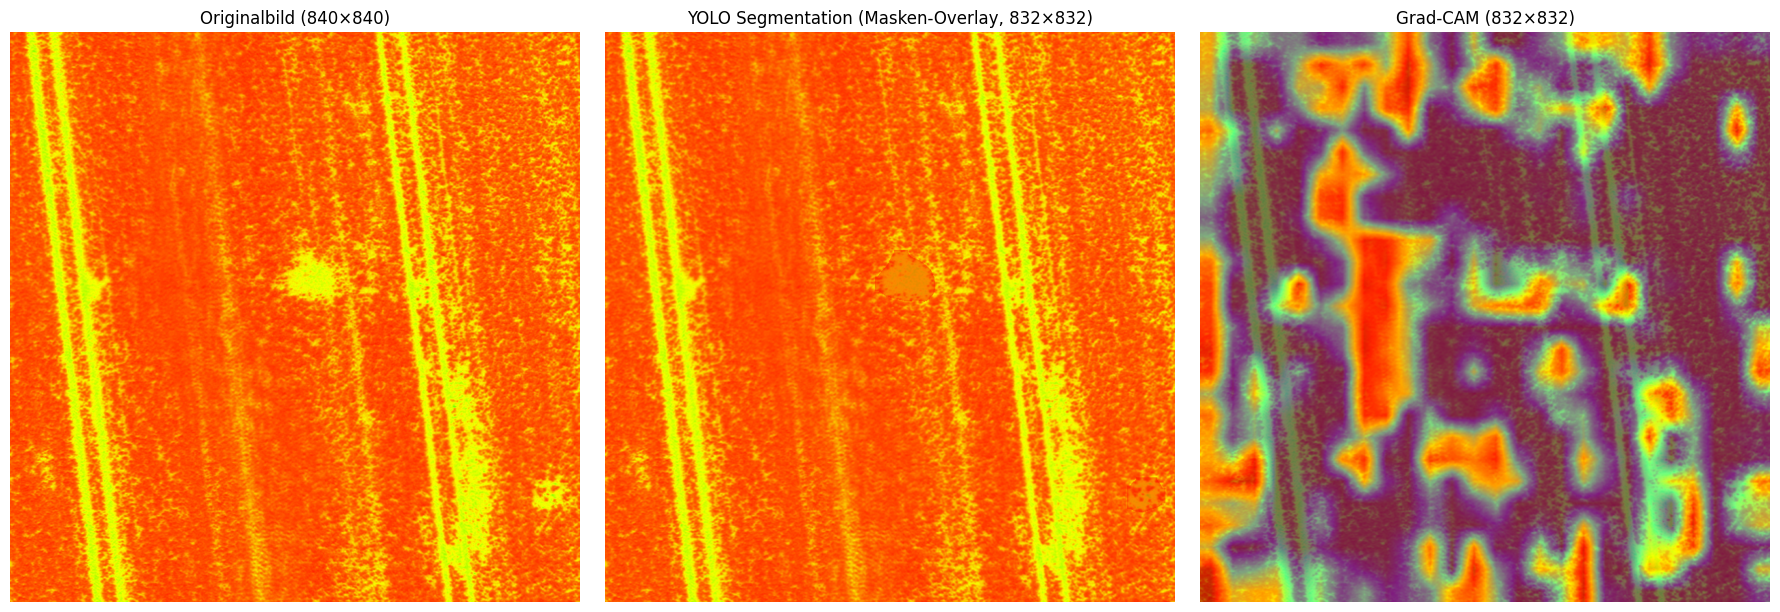

In [ ]:
#Ausgabe als Figure: Originalbild | YOLO Segmentation | GradCAM (ohne Files zu speichern)

import matplotlib.pyplot as plt

# 1) Original (840×840)
orig = img_rgb  # RGB uint8, (840, 840, 3)

# 2) YOLO Segmentation 
img_yolo = img_lb.copy()  # RGB uint8, (832, 832, 3)

if r.masks is not None:
    masks = r.masks.data.detach().cpu().numpy()          # (n, 832, 832)
    union = (masks.max(axis=0) > 0.5).astype(np.uint8)   # (832, 832) 0/1

    # Overlay-Farbe (rot) + Alpha
    alpha = 0.45
    overlay = np.zeros_like(img_yolo, dtype=np.uint8)
    overlay[..., 0] = 255  # Rot in RGB
    img_yolo = np.where(union[..., None] == 1,
                        (img_yolo * (1 - alpha) + overlay * alpha).astype(np.uint8),
                        img_yolo)
else:
    
    pass

# 3) GradCAM Overlay
gradcam_vis = show_cam_on_image(img_lb.astype(np.float32) / 255.0, grayscale_cam, use_rgb=True)  # RGB uint8-like

# ---- Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(orig)
axes[0].set_title("Originalbild (840×840)")
axes[0].axis("off")

axes[1].imshow(img_yolo)
axes[1].set_title("YOLO Segmentation (Masken-Overlay, 832×832)")
axes[1].axis("off")

axes[2].imshow(gradcam_vis)
axes[2].set_title("Grad-CAM (832×832)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

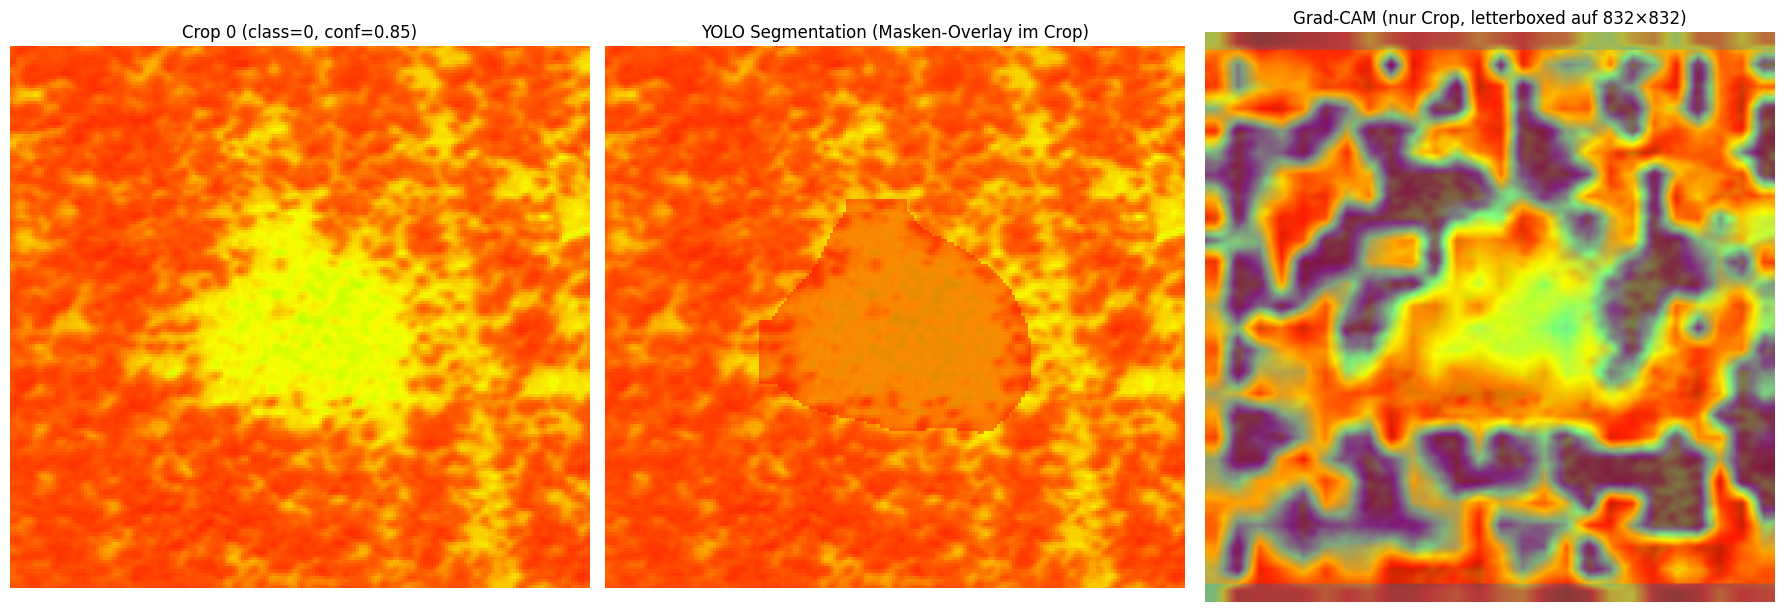

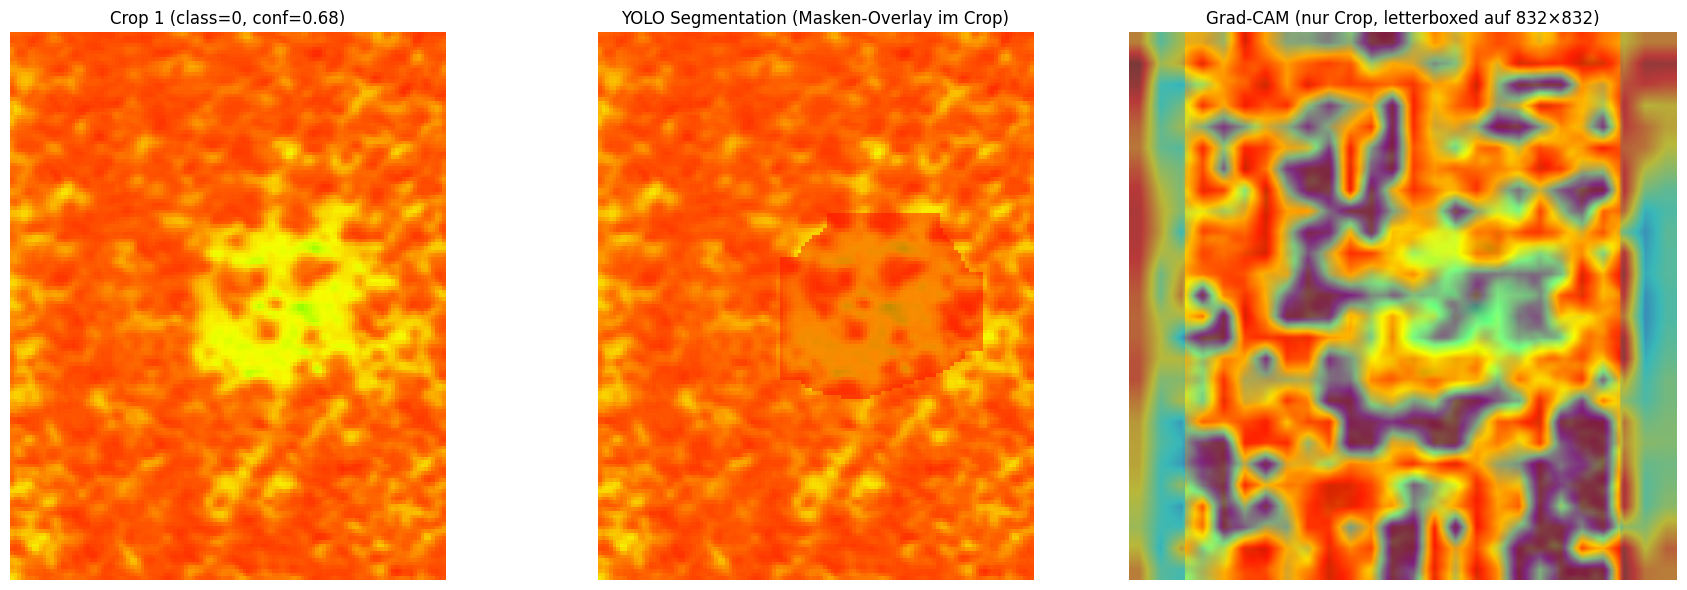

In [ ]:
#Grad-CAM nur auf YOLO-Segmente

import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt

from ultralytics.data.augment import LetterBox
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

IMG_SZ = 832
PAD = 50          # 50px in jede Richtung
MIN_AREA = 50     # optional: sehr kleine Segmente ignorieren
CONF = 0.25
IOU = 0.7

# 1) YOLO Predict
results = yolo.predict(
    source=IMAGE_PATH,
    imgsz=IMG_SZ,
    conf=CONF,
    iou=IOU,
    device=0 if device == "cuda" else "cpu",
    verbose=False
)
r = results[0]

# 2) Letterboxed Bild
lb = LetterBox(new_shape=(IMG_SZ, IMG_SZ), auto=False, scaleFill=False, stride=32)
img_lb = lb(image=img_rgb)  # RGB uint8 (832, 832, 3)

if r.masks is None or r.boxes is None:
    raise RuntimeError("Keine Masken/Boxen gefunden. Prüfe conf/iou oder ob das Modell wirklich segmentiert.")

masks = r.masks.data.detach().cpu().numpy()  # (n, 832, 832)
cls = r.boxes.cls.detach().cpu().numpy().astype(int)  # (n,)
conf = r.boxes.conf.detach().cpu().numpy()            # (n,)

# 3) Grad-CAM Setup (einmal erstellen, dann pro Crop aufrufen)
torch.set_grad_enabled(True)
net.eval()
for p in net.parameters():
    p.requires_grad_(True)

cam = GradCAM(model=net, target_layers=[target_layer])

def bbox_from_mask(mask01: np.ndarray):
    """mask01: (H,W) bool/0-1 -> xyxy bbox oder None"""
    ys, xs = np.where(mask01)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    return int(x1), int(y1), int(x2), int(y2)

def pad_and_clip_xyxy(x1, y1, x2, y2, pad, w, h):
    x1p = max(0, x1 - pad)
    y1p = max(0, y1 - pad)
    x2p = min(w - 1, x2 + pad)
    y2p = min(h - 1, y2 + pad)
    return x1p, y1p, x2p, y2p

# 4) Pro Segment: Crop -> preprocess -> GradCAM -> Visualisieren
H, W = img_lb.shape[:2]
idxs = [i for i in range(len(masks)) if cls[i] == CLASS_ID]

if len(idxs) == 0:
    raise RuntimeError(f"Keine Instanz mit CLASS_ID={CLASS_ID} gefunden.")

for k, i in enumerate(idxs):
    mask01 = masks[i] > 0.5
    if mask01.sum() < MIN_AREA:
        continue

    bb = bbox_from_mask(mask01)
    if bb is None:
        continue

    x1, y1, x2, y2 = bb
    x1, y1, x2, y2 = pad_and_clip_xyxy(x1, y1, x2, y2, PAD, W, H)

    crop = img_lb[y1:y2+1, x1:x2+1, :].copy()
    if crop.size == 0:
        continue

    mask_crop = mask01[y1:y2+1, x1:x2+1]

    # 4a) Crop für YOLO/GradCAM auf IMG_SZ bringen (LetterBox)
    crop_tensor = preprocess_ultralytics(crop, imgsz=IMG_SZ, device=device)
    crop_tensor = crop_tensor.clone().detach().to(device)
    crop_tensor.requires_grad_(True)

    # 4b) GradCAM nur auf diesem Crop
    net.zero_grad(set_to_none=True)
    grayscale_cam = cam(input_tensor=crop_tensor, targets=[YOLOScoreTarget(CLASS_ID)])[0]  # (832, 832)

    # 4c) letterboxed Crop-Bild in 832×832
    crop_lb = lb(image=crop)  # RGB uint8 (832, 832, 3)

    gradcam_vis = show_cam_on_image(crop_lb.astype(np.float32)/255.0, grayscale_cam, use_rgb=True)

    # 4d) YOLO-Seg Overlay im Crop
    crop_yolo = crop.copy()
    overlay = np.zeros_like(crop_yolo, dtype=np.uint8)
    overlay[..., 0] = 255  # rot
    alpha = 0.45
    crop_yolo = np.where(mask_crop[..., None],
                         (crop_yolo * (1 - alpha) + overlay * alpha).astype(np.uint8),
                         crop_yolo)

    # 4e) Anzeige: Original Crop | YOLO Seg Crop | GradCAM Crop
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(crop)
    axes[0].set_title(f"Crop {k} (class={CLASS_ID}, conf={conf[i]:.2f})")
    axes[0].axis("off")

    axes[1].imshow(crop_yolo)
    axes[1].set_title("YOLO Segmentation (Masken-Overlay im Crop)")
    axes[1].axis("off")

    axes[2].imshow(gradcam_vis)
    axes[2].set_title("Grad-CAM (nur Crop, letterboxed auf 832×832)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

Baseline score (sum conf, class 0): 0.0


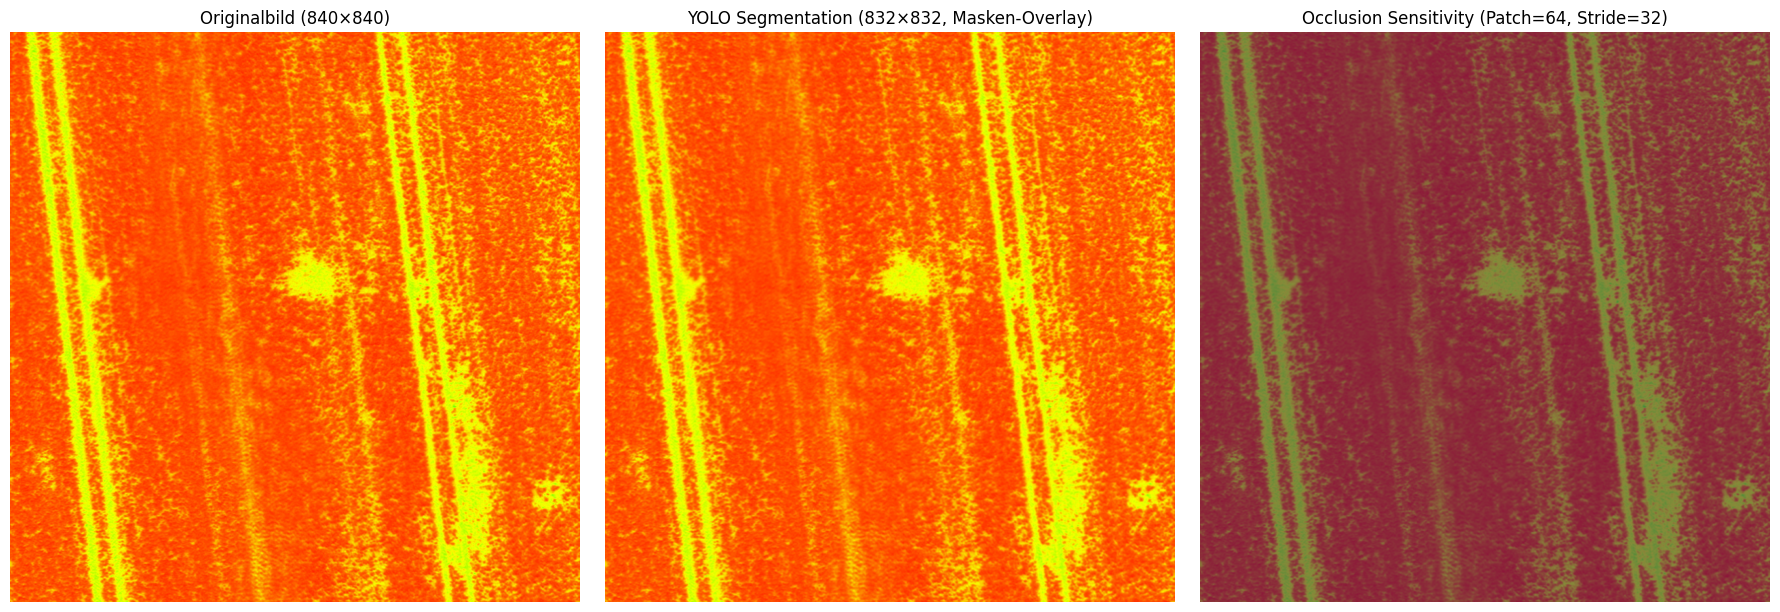

In [ ]:
#Occlusion Sensitivity (Patch-Masking) für YOLO-Seg

import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics.data.augment import LetterBox

IMG_SZ = 832     
CONF = 0.25
IOU = 0.7

PATCH = 64       # Occlusion-Fenstergröße (px)
STRIDE = 32      # Schrittweite (px)
PAD = 50         
MASK_MODE = "mean"  # "mean" oder "zero"

# ----------------------------
# Hilfsfunktionen
# ----------------------------

def yolo_predict_on_rgb(yolo, img_rgb_uint8, imgsz=832, conf=0.25, iou=0.7, device="cpu"):
    """Ultralytics predict auf einem numpy RGB Bild (kein Dateipfad)."""
    res = yolo.predict(
        source=img_rgb_uint8,
        imgsz=imgsz,
        conf=conf,
        iou=iou,
        device=0 if device == "cuda" else "cpu",ﬁ
        verbose=False
    )[0]
    return res

def mask_union_for_class(result, class_id=0, thr=0.5):
    """Union-Maske für alle Instanzen einer Klasse. Rückgabe: (H,W) bool oder None."""
    if result.masks is None or result.boxes is None:
        return None
    cls = result.boxes.cls.detach().cpu().numpy().astype(int)
    masks = result.masks.data.detach().cpu().numpy()  # (n,H,W)
    idx = np.where(cls == class_id)[0]
    if len(idx) == 0:
        return None
    union = (masks[idx].max(axis=0) > thr)
    return union

def score_for_class(result, class_id=0):
    """
    Scoring-Funktion (Target) für Occlusion:
    Summe der confidences aller Detektionen von class_id.
    (Robust und einfach. Alternativ: max(conf) statt sum(conf).)
    """
    if result.boxes is None:
        return 0.0
    cls = result.boxes.cls.detach().cpu().numpy().astype(int)
    conf = result.boxes.conf.detach().cpu().numpy()
    mask = (cls == class_id)
    if mask.sum() == 0:
        return 0.0
    return float(conf[mask].sum())

def apply_occlusion(img_rgb, x1, y1, x2, y2, mode="mean"):
    out = img_rgb.copy()
    if mode == "mean":
        fill = out.mean(axis=(0, 1), keepdims=True).astype(out.dtype)  # (1,1,3)
        out[y1:y2, x1:x2] = fill
    elif mode == "zero":
        out[y1:y2, x1:x2] = 0
    else:
        raise ValueError("MASK_MODE muss 'mean' oder 'zero' sein")
    return out

def normalize01(x):
    x = x.astype(np.float32)
    x = x - np.nanmin(x)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return x

# ----------------------------
# 1) Bild laden + Letterbox
# ----------------------------

img_rgb = load_tif_as_rgb_uint8(IMAGE_PATH)  # (840,840,3)

lb = LetterBox(new_shape=(IMG_SZ, IMG_SZ), auto=False, scaleFill=False, stride=32)
img_lb = lb(image=img_rgb)  # (832,832,3) RGB uint8

# ----------------------------
# 2) Baseline prediction + Baseline score
# ----------------------------

base_res = yolo_predict_on_rgb(yolo, img_lb, imgsz=IMG_SZ, conf=CONF, iou=IOU, device=device)
base_score = score_for_class(base_res, CLASS_ID)

union = mask_union_for_class(base_res, CLASS_ID, thr=0.5)
img_yolo = img_lb.copy()
if union is not None:
    alpha = 0.45
    overlay = np.zeros_like(img_yolo, dtype=np.uint8)
    overlay[..., 0] = 255  # rot (RGB)
    img_yolo = np.where(union[..., None],
                        (img_yolo * (1 - alpha) + overlay * alpha).astype(np.uint8),
                        img_yolo)

print("Baseline score (sum conf, class 0):", base_score)

# ----------------------------
# 3) Occlusion loop -> Heatmap (Score-Drop)
# ----------------------------

H, W = img_lb.shape[:2]
heat = np.zeros((H, W), dtype=np.float32)
count = np.zeros((H, W), dtype=np.float32)

for y in range(0, H - PATCH + 1, STRIDE):
    for x in range(0, W - PATCH + 1, STRIDE):
        x1, y1 = x, y
        x2, y2 = x + PATCH, y + PATCH

        occluded = apply_occlusion(img_lb, x1, y1, x2, y2, mode=MASK_MODE)

        res_occ = yolo_predict_on_rgb(yolo, occluded, imgsz=IMG_SZ, conf=CONF, iou=IOU, device=device)
        occ_score = score_for_class(res_occ, CLASS_ID)

        drop = base_score - occ_score
        heat[y1:y2, x1:x2] += drop
        count[y1:y2, x1:x2] += 1.0

# Mittelwert pro Pixel
heat = np.divide(heat, np.maximum(count, 1.0))
heat01 = normalize01(heat)

# Heatmap als Overlay visualisieren
heat_color = cv2.applyColorMap((heat01 * 255).astype(np.uint8), cv2.COLORMAP_JET)
heat_color = cv2.cvtColor(heat_color, cv2.COLOR_BGR2RGB)

beta = 0.45
occ_vis = (img_lb.astype(np.float32) * (1 - beta) + heat_color.astype(np.float32) * beta).clip(0, 255).astype(np.uint8)

# ----------------------------
# 4) Ausgabe: Original | YOLO Segmentation | Occlusion Heatmap
# ----------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Originalbild (840×840)")
axes[0].axis("off")

axes[1].imshow(img_yolo)
axes[1].set_title("YOLO Segmentation (832×832, Masken-Overlay)")
axes[1].axis("off")

axes[2].imshow(occ_vis)
axes[2].set_title(f"Occlusion Sensitivity (Patch={PATCH}, Stride={STRIDE})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

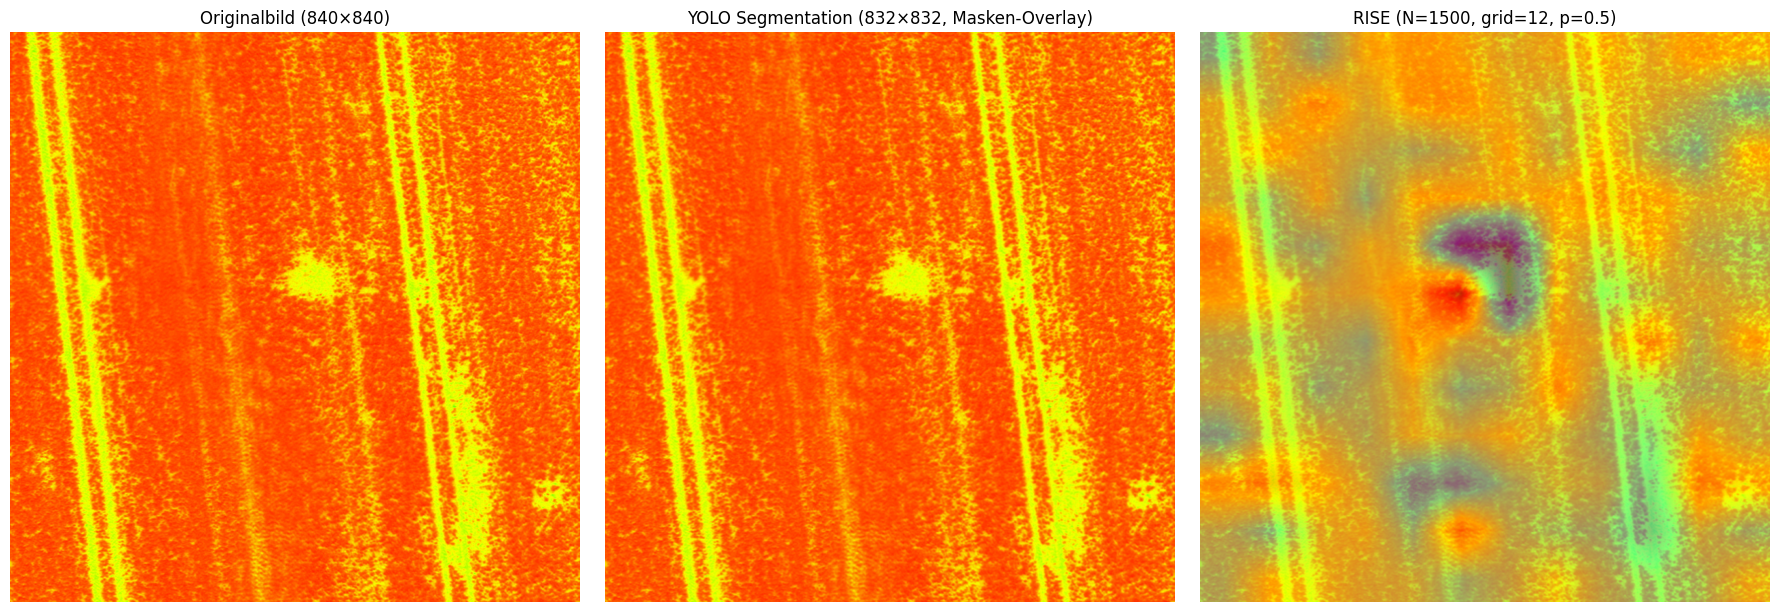

In [ ]:
# RISE (Randomized Input Sampling for Explanation) für YOLO-Seg

import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics.data.augment import LetterBox

IMG_SZ = 832
CONF = 0.25
IOU = 0.7

N_MASKS = 1500        # 300-2000 üblich; mehr = glatter, aber langsamer
S_GRID = 12           # Gitterauflösung (8..16 üblich); höher = feinere Masken
P_KEEP = 0.5         # Wahrscheinlichkeit, dass eine Zelle "sichtbar" bleibt
BATCH = 16           # wie viele Masken pro Batch (für predict) – je nach VRAM/CPU

# ----------------------------
# Hilfsfunktionen
# ----------------------------

def yolo_predict_on_rgb(yolo, img_rgb_uint8, imgsz=832, conf=0.25, iou=0.7, device="cpu"):
    res = yolo.predict(
        source=img_rgb_uint8,
        imgsz=imgsz,
        conf=conf,
        iou=iou,
        device=0 if device == "cuda" else "cpu",
        verbose=False
    )[0]
    return res

def score_for_class(result, class_id=0, mode="sum"):
    """
    Target-Score für RISE:
    - "sum": Summe der confidences aller Detektionen der Klasse
    - "max": maximale confidence der Klasse (oft schärfer)
    """
    if result.boxes is None:
        return 0.0
    cls = result.boxes.cls.detach().cpu().numpy().astype(int)
    conf = result.boxes.conf.detach().cpu().numpy()
    m = (cls == class_id)
    if m.sum() == 0:
        return 0.0
    return float(conf[m].sum()) if mode == "sum" else float(conf[m].max())

def mask_union_for_class(result, class_id=0, thr=0.5):
    if result.masks is None or result.boxes is None:
        return None
    cls = result.boxes.cls.detach().cpu().numpy().astype(int)
    masks = result.masks.data.detach().cpu().numpy()
    idx = np.where(cls == class_id)[0]
    if len(idx) == 0:
        return None
    return (masks[idx].max(axis=0) > thr)

def normalize01(x):
    x = x.astype(np.float32)
    x = x - np.nanmin(x)
    mx = np.nanmax(x)
    if mx > 0:
        x = x / mx
    return x

def generate_rise_masks(n, H, W, s=8, p_keep=0.5, seed=0):
    """
    RISE-Masken:
    - erst low-res (s×s) Bernoulli
    - dann bilinear auf (H,W) hochskalieren
    """
    rng = np.random.default_rng(seed)
    masks = []
    for _ in range(n):
        m_small = (rng.random((s, s)) < p_keep).astype(np.float32)
        m = cv2.resize(m_small, (W, H), interpolation=cv2.INTER_LINEAR)
        masks.append(m)
    return np.stack(masks, axis=0)  # (n,H,W) float32 in [0,1]

# ----------------------------
# 1) Bild laden + Letterbox + Baseline YOLO
# ----------------------------

img_rgb = load_tif_as_rgb_uint8(IMAGE_PATH)  # (840,840,3)

lb = LetterBox(new_shape=(IMG_SZ, IMG_SZ), auto=False, scaleFill=False, stride=32)
img_lb = lb(image=img_rgb)  # (832,832,3) RGB uint8

base_res = yolo_predict_on_rgb(yolo, img_lb, imgsz=IMG_SZ, conf=CONF, iou=IOU, device=device)
union = mask_union_for_class(base_res, CLASS_ID, thr=0.5)

img_yolo = img_lb.copy()
if union is not None:
    alpha = 0.45
    overlay = np.zeros_like(img_yolo, dtype=np.uint8)
    overlay[..., 0] = 255  # rot (RGB)
    img_yolo = np.where(union[..., None],
                        (img_yolo * (1 - alpha) + overlay * alpha).astype(np.uint8),
                        img_yolo)

# ----------------------------
# 2) RISE Masken generieren
# ----------------------------

H, W = img_lb.shape[:2]
masks = generate_rise_masks(N_MASKS, H, W, s=S_GRID, p_keep=P_KEEP, seed=42)  # (N,H,W)

# ----------------------------
# 3) Masken anwenden + Scores sammeln
# ----------------------------

scores = np.zeros((N_MASKS,), dtype=np.float32)

# Masken auf Bild anwenden.
img_f = img_lb.astype(np.float32)

for start in range(0, N_MASKS, BATCH):
    end = min(N_MASKS, start + BATCH)
    batch_imgs = []
    for i in range(start, end):
        m = masks[i][..., None]  # (H,W,1)
        masked = (img_f * m)     # (H,W,3)
        masked = np.clip(masked, 0, 255).astype(np.uint8)
        batch_imgs.append(masked)

    batch_results = yolo.predict(
        source=batch_imgs,
        imgsz=IMG_SZ,
        conf=CONF,
        iou=IOU,
        device=0 if device == "cuda" else "cpu",
        verbose=False
    )

    for j, res in enumerate(batch_results):
        scores[start + j] = score_for_class(res, CLASS_ID, mode="max")  # "max" ist oft schärfer

# ----------------------------
# 4) Saliency berechnen
# sal = (1 / (N * p)) * Σ score_i * mask_i
# ----------------------------

sal = (scores[:, None, None] * masks).sum(axis=0)  # (H,W)
sal = sal / (N_MASKS * max(P_KEEP, 1e-6))
sal01 = normalize01(sal)

# Visualisierung als Overlay
sal_color = cv2.applyColorMap((sal01 * 255).astype(np.uint8), cv2.COLORMAP_JET)
sal_color = cv2.cvtColor(sal_color, cv2.COLOR_BGR2RGB)

beta = 0.45
rise_vis = (img_lb.astype(np.float32) * (1 - beta) + sal_color.astype(np.float32) * beta).clip(0, 255).astype(np.uint8)

# ----------------------------
# 5) Ausgabe: Original | YOLO Segmentation | RISE Heatmap
# ----------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Originalbild (840×840)")
axes[0].axis("off")

axes[1].imshow(img_yolo)
axes[1].set_title("YOLO Segmentation (832×832, Masken-Overlay)")
axes[1].axis("off")

axes[2].imshow(rise_vis)
axes[2].set_title(f"RISE (N={N_MASKS}, grid={S_GRID}, p={P_KEEP})")
axes[2].axis("off")

plt.tight_layout()
plt.show()